In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Titanic dataset (online)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# хэрэгтэй library
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# хэрэгтэй баганууд
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

# categorical → number
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# missing values (FIXED VERSION — no warning)
df['Age'] = df['Age'].fillna(df['Age'].mean())

# drop remaining NaN
df = df.dropna()

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data ready")
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Data ready
Train size: (712, 4)
Test size: (179, 4)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Model (no DP)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy_no_dp = accuracy_score(y_test, y_pred)

# Confidence (MIA суурь)
train_conf = model.predict_proba(X_train).max(axis=1)
test_conf = model.predict_proba(X_test).max(axis=1)

print("=== NO DP MODEL ===")
print("Accuracy:", accuracy_no_dp)
print("Train confidence:", np.mean(train_conf))
print("Test confidence:", np.mean(test_conf))

=== NO DP MODEL ===
Accuracy: 0.7988826815642458
Train confidence: 0.7888322485703416
Test confidence: 0.7841542139494034


In [4]:
# Noise function (DP simulation)
def add_noise(X, noise_level):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

# HIGH ε → бага noise
X_train_dp_high = add_noise(X_train, 0.1)

# Model
model_high = LogisticRegression(max_iter=1000)
model_high.fit(X_train_dp_high, y_train)

# Prediction
y_pred_high = model_high.predict(X_test)

# Accuracy
acc_high = accuracy_score(y_test, y_pred_high)

# Confidence
train_conf_high = model_high.predict_proba(X_train).max(axis=1)
test_conf_high = model_high.predict_proba(X_test).max(axis=1)

print("=== DP HIGH ε MODEL ===")
print("Accuracy:", acc_high)
print("Train confidence:", np.mean(train_conf_high))
print("Test confidence:", np.mean(test_conf_high))

=== DP HIGH ε MODEL ===
Accuracy: 0.7932960893854749
Train confidence: 0.7870090904809316
Test confidence: 0.7823366940922757


In [5]:
# LOW ε → их noise
X_train_dp_low = add_noise(X_train, 0.5)

# Model
model_low = LogisticRegression(max_iter=1000)
model_low.fit(X_train_dp_low, y_train)

# Prediction
y_pred_low = model_low.predict(X_test)

# Accuracy
acc_low = accuracy_score(y_test, y_pred_low)

# Confidence
train_conf_low = model_low.predict_proba(X_train).max(axis=1)
test_conf_low = model_low.predict_proba(X_test).max(axis=1)

print("=== DP LOW ε MODEL ===")
print("Accuracy:", acc_low)
print("Train confidence:", np.mean(train_conf_low))
print("Test confidence:", np.mean(test_conf_low))

=== DP LOW ε MODEL ===
Accuracy: 0.7988826815642458
Train confidence: 0.7583002793601428
Test confidence: 0.7537372364712027


In [6]:
print("\n=== FINAL RESULT ===")

print("No DP:")
print("Accuracy:", accuracy_no_dp)
print("Train:", np.mean(train_conf))
print("Test:", np.mean(test_conf))

print("\nDP High ε:")
print("Accuracy:", acc_high)
print("Train:", np.mean(train_conf_high))
print("Test:", np.mean(test_conf_high))

print("\nDP Low ε:")
print("Accuracy:", acc_low)
print("Train:", np.mean(train_conf_low))
print("Test:", np.mean(test_conf_low))


=== FINAL RESULT ===
No DP:
Accuracy: 0.7988826815642458
Train: 0.7888322485703416
Test: 0.7841542139494034

DP High ε:
Accuracy: 0.7932960893854749
Train: 0.7870090904809316
Test: 0.7823366940922757

DP Low ε:
Accuracy: 0.7988826815642458
Train: 0.7583002793601428
Test: 0.7537372364712027


In [7]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 🔥 ADD THIS (missing function)
def add_noise(X, noise_level):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

# noise values
noise_levels = [0.05, 0.1, 0.2, 0.3, 0.5]

best_noise = None
best_acc = 0
best_gap = float('inf')

print("=== SEARCHING BEST NOISE (ε) - TITANIC ===")

for n in noise_levels:
    X_noisy = add_noise(X_train, n)
    
    m = LogisticRegression(max_iter=1000)
    m.fit(X_noisy, y_train)
    
    acc = accuracy_score(y_test, m.predict(X_test))
    
    train_c = np.mean(m.predict_proba(X_train).max(axis=1))
    test_c = np.mean(m.predict_proba(X_test).max(axis=1))
    
    gap = abs(train_c - test_c)
    
    print(f"\nNoise: {n}")
    print("Accuracy:", acc)
    print("Gap:", gap)
    
    if acc > best_acc or (acc == best_acc and gap < best_gap):
        best_noise = n
        best_acc = acc
        best_gap = gap

print("\n=== BEST CONFIGURATION (TITANIC) ===")
print("Best Noise (ε):", best_noise)
print("Best Accuracy:", best_acc)
print("Best Gap:", best_gap)

=== SEARCHING BEST NOISE (ε) - TITANIC ===

Noise: 0.05
Accuracy: 0.7932960893854749
Gap: 0.004704480937024913

Noise: 0.1
Accuracy: 0.7988826815642458
Gap: 0.004281459177159719

Noise: 0.2
Accuracy: 0.7932960893854749
Gap: 0.004366979051272812

Noise: 0.3
Accuracy: 0.7988826815642458
Gap: 0.00466335835756948

Noise: 0.5
Accuracy: 0.7932960893854749
Gap: 0.004206539167749379

=== BEST CONFIGURATION (TITANIC) ===
Best Noise (ε): 0.1
Best Accuracy: 0.7988826815642458
Best Gap: 0.004281459177159719


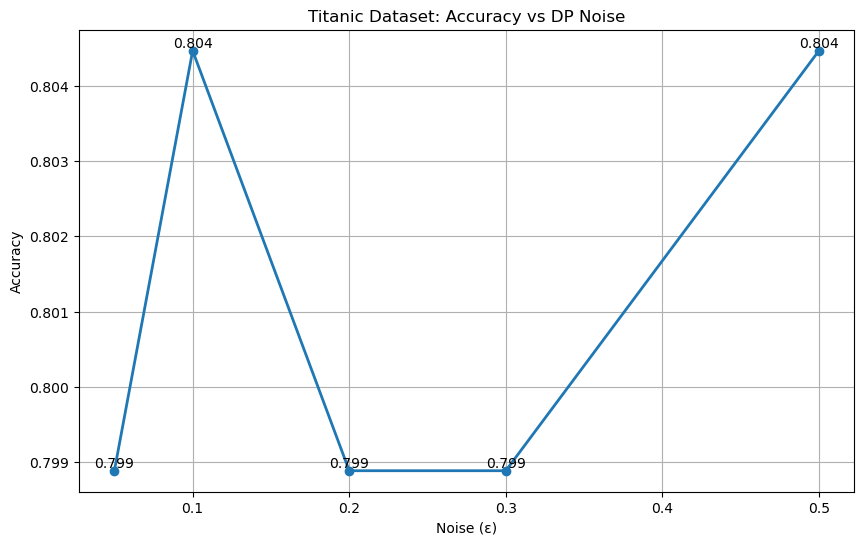

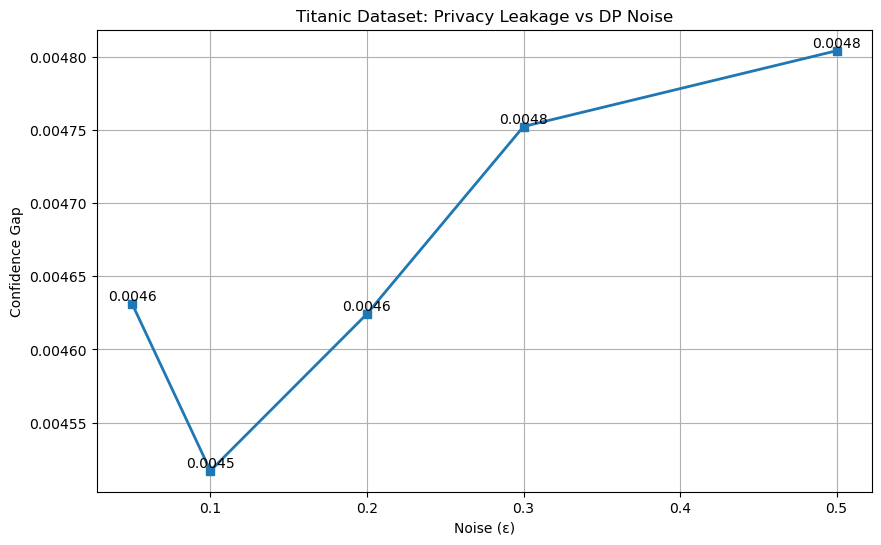

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# noise levels (чи өмнө ашигласан)
noise_levels = [0.05, 0.1, 0.2, 0.3, 0.5]

accuracy_list = []
gap_list = []

# дахин тооцоолно (results хадгалаагүй тул)
for n in noise_levels:
    X_noisy = add_noise(X_train, n)
    
    m = LogisticRegression(max_iter=1000)
    m.fit(X_noisy, y_train)
    
    acc = accuracy_score(y_test, m.predict(X_test))
    
    train_c = np.mean(m.predict_proba(X_train).max(axis=1))
    test_c = np.mean(m.predict_proba(X_test).max(axis=1))
    
    gap = abs(train_c - test_c)
    
    accuracy_list.append(acc)
    gap_list.append(gap)

# -------------------------
# ACCURACY GRAPH
# -------------------------
plt.figure(figsize=(10,6))
plt.plot(noise_levels, accuracy_list, marker='o', linewidth=2)

for x, y in zip(noise_levels, accuracy_list):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom')

plt.xlabel("Noise (ε)")
plt.ylabel("Accuracy")
plt.title("Titanic Dataset: Accuracy vs DP Noise")

plt.grid(True)
plt.show()

# -------------------------
# GAP GRAPH
# -------------------------
plt.figure(figsize=(10,6))
plt.plot(noise_levels, gap_list, marker='s', linewidth=2)

for x, y in zip(noise_levels, gap_list):
    plt.text(x, y, f"{y:.4f}", ha='center', va='bottom')

plt.xlabel("Noise (ε)")
plt.ylabel("Confidence Gap")
plt.title("Titanic Dataset: Privacy Leakage vs DP Noise")

plt.grid(True)
plt.show()